In [ ]:
from utils.SnakeGame import SnakeGame  # Ensure you have this module
import numpy as np
import time
import random

# Function to choose the action using epsilon-greedy strategy
def choose_action(Q, state, epsilon):
    if np.random.rand() < epsilon:  # Explore: choose random action
        return np.random.choice([0, 1, 2])
    else:  # Exploit: choose best known action
        return np.argmax(Q[state])

# Function to update the Q-table using the Q-learning update rule
def update_Q(Q, old_state, state, action, reward, learning_rate, discount):
    best_future_value = np.max(Q[state])  # Best future value from the next state
    Q[old_state, action] += learning_rate * (reward + discount * best_future_value - Q[old_state, action])

# Main Q-learning loop
def Q_learning(game, episodes, learning_rate, discount, start_exploration, end_exploration, render_from_episode=-1,Training =False):
    Q = np.zeros((64, 3))  # Assuming 64 states and 3 possible actions (left, straight, right)
    scores = []

    try:
        for episode, epsilon in enumerate(np.linspace(start_exploration, end_exploration, episodes)):
            game.init_game()
            old_state = game.get_state()
            continues = True
            
            while continues:
                # Choose an action based on current state
                action = choose_action(Q, old_state, epsilon)
                
                # Perform the action in the game
                continues, reward, state = game.step(action)
                
                # Update Q-table based on the experience
                update_Q(Q, old_state, state, action, reward, learning_rate, discount)
                
                # Move to the next state
                old_state = state

                # Optional: Render the game after a certain number of episodes
                
                if (render_from_episode <= (episode - episodes)) and (not Training):
                    game.render(episode=episode, high_score=np.max(scores), clear=True)
                    time.sleep(1 / 60)
            
            scores.append(game.score())  # Track the score for each episode

    except KeyboardInterrupt:
        print("Training interrupted by user.")
        return Q, scores
    
    return Q, scores


#### Scores Without Optimization

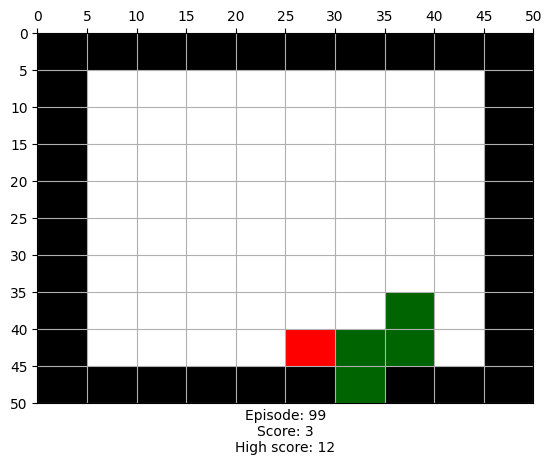

Average Score: 1.97
Best Score: 12


In [2]:
# Run the function with initial parameters and tune them
episodes = 100
learning_rate = 0.1
discount = 0.9
start_exploration = 1.0  # High exploration at the beginning
end_exploration = 0.01   # Low exploration at the end

Q, scores = Q_learning(SnakeGame(), episodes, learning_rate, discount, start_exploration, end_exploration)

# Print results
print(f"Average Score: {np.mean(scores)}")
print(f"Best Score: {np.max(scores)}")


In [24]:
# Function to run experiments with different hyperparameters
def parameter_search():
    # Define ranges for hyperparameters
    episode_options = [200, 300, 600]
    learning_rate_options = [0.001, 0.01, 0.1, 0.5]
    discount_options = [0.4, 0.5, 0.9]
    exploration_start_options = [1.0, 0.5]
    exploration_end_options = [0.01, 0.1]

    # Track the best performance and parameters
    best_score = -np.inf
    best_params = {}
    
    # Iterate over all combinations of hyperparameters
    for episodes in episode_options:
        for learning_rate in learning_rate_options:
            for discount in discount_options:
                for start_exploration in exploration_start_options:
                    for end_exploration in exploration_end_options:
                        print(f"Testing params: Episodes={episodes}, LR={learning_rate}, Discount={discount}, EpsilonStart={start_exploration}, EpsilonEnd={end_exploration}")
                        
                        # Initialize the game and train
                        game = SnakeGame()
                        Q, scores = Q_learning(game, episodes, learning_rate, discount, start_exploration, end_exploration, -1,True)
                        
                        # Calculate the average score across all episodes
                        avg_score = np.mean(scores)
                        print(f"Average Score: {avg_score}")
                        
                        # Update best parameters if the current combination is better
                        if avg_score > best_score:
                            best_score = avg_score
                            best_params = {
                                'episodes': episodes,
                                'learning_rate': learning_rate,
                                'discount': discount,
                                'start_exploration': start_exploration,
                                'end_exploration': end_exploration
                            }
                        
                        print(f"Best Score So Far: {best_score} with params {best_params}")
                        print()
                        print("--------------------------------------------------")
    
    # Print the best parameters found during the search
    print("\nBest Hyperparameters Found:")
    for key, value in best_params.items():
        print(f"{key}: {value}")
    print(f"Best Average Score: {best_score}")
    return best_score, best_params


In [25]:
# Run the parameter search
parameter_search()

Testing params: Episodes=200, LR=0.001, Discount=0.4, EpsilonStart=1.0, EpsilonEnd=0.01
Average Score: 2.07
Best Score So Far: 2.07 with params {'episodes': 200, 'learning_rate': 0.001, 'discount': 0.4, 'start_exploration': 1.0, 'end_exploration': 0.01}

--------------------------------------------------
Testing params: Episodes=200, LR=0.001, Discount=0.4, EpsilonStart=1.0, EpsilonEnd=0.1
Average Score: 1.8
Best Score So Far: 2.07 with params {'episodes': 200, 'learning_rate': 0.001, 'discount': 0.4, 'start_exploration': 1.0, 'end_exploration': 0.01}

--------------------------------------------------
Testing params: Episodes=200, LR=0.001, Discount=0.4, EpsilonStart=0.5, EpsilonEnd=0.01
Average Score: 3.375
Best Score So Far: 3.375 with params {'episodes': 200, 'learning_rate': 0.001, 'discount': 0.4, 'start_exploration': 0.5, 'end_exploration': 0.01}

--------------------------------------------------
Testing params: Episodes=200, LR=0.001, Discount=0.4, EpsilonStart=0.5, EpsilonEnd

(4.615,
 {'episodes': 600,
  'learning_rate': 0.01,
  'discount': 0.4,
  'start_exploration': 0.5,
  'end_exploration': 0.01})

#### Scores with Optimization

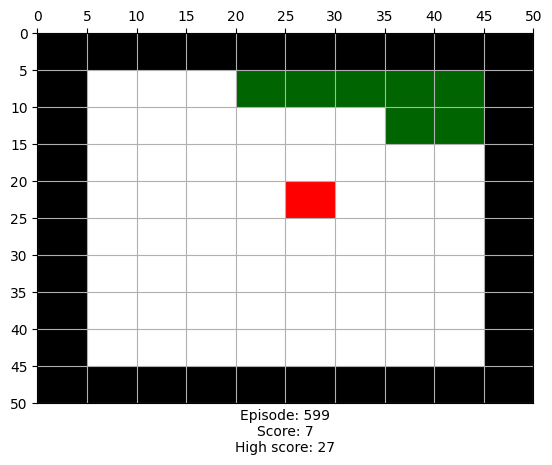

In [ ]:
# Run the function with initial parameters and tune them
episodes = 600
learning_rate = 0.01
discount = 0.5
start_exploration = 0.5  # High exploration at the beginning
end_exploration = 0.01   # Low exploration at the end

Q, scores = Q_learning(SnakeGame(), episodes, learning_rate, discount, start_exploration, end_exploration)


### OBSERVATION: In the quest for optimal parameters, it became evident that all four parameters depended on the episodes, with each episode yielding its own best parameters. Notably, the ideal learning rate consistently fell between 0.01 and 0.001, while the optimal discount factor ranged from 0.4 to 0.5. However, the starting and ending exploration values remained constant throughout all experiments.

#### Highest SCORE: My snake highest score ranges from 30 to 26, there is much randomization in the system which couls be improved as the next learning task.